In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')
path = "/content/drive/MyDrive"
os.chdir(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import gc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, confusion_matrix,
                              precision_recall_curve, average_precision_score,
                              f1_score)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_parquet('chicago_train.parquet')
test_df  = pd.read_parquet('chicago_test.parquet')

feature_cols = [c for c in train_df.columns if c != 'Arrest']
X_train = train_df[feature_cols]
y_train = train_df['Arrest']
X_test  = test_df[feature_cols]
y_test  = test_df['Arrest']

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

In [ ]:
# evaluation function
def evaluate_model(y_true, y_pred, y_prob, model_name):
    auc = roc_auc_score(y_true, y_prob)
    ap  = average_precision_score(y_true, y_prob)
    f1  = f1_score(y_true, y_pred, average='macro')
    print(f"ROC-AUC:           {auc:.4f}")
    print(f"Average Precision: {ap:.4f}")
    print(f"F1-macro:          {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Arrest', 'Arrest']))
    return {'model': model_name, 'AUC': auc, 'AP': ap, 'F1_macro': f1}

results = {}

In [ ]:
# Logistic Regression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=300,
        solver='saga',
        n_jobs=-1,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)

y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = lr_pipeline.predict(X_test)

joblib.dump(lr_pipeline, 'model_lr.pkl')

['model_lr.pkl']

In [ ]:
evaluate_model(y_test, y_pred_lr, y_prob_lr, 'Logistic Regression')
auc_lr = round(float(roc_auc_score(y_test, y_prob_lr)), 4)

ROC-AUC:           0.8354
Average Precision: 0.5986
F1-macro:          0.7176

Classification Report:
              precision    recall  f1-score   support

   No Arrest       0.90      0.93      0.92    198579
      Arrest       0.56      0.48      0.52     37535

    accuracy                           0.86    236114
   macro avg       0.73      0.71      0.72    236114
weighted avg       0.85      0.86      0.85    236114



In [4]:
auc_lr=0.8354
lr_pipeline = joblib.load('model_lr.pkl')

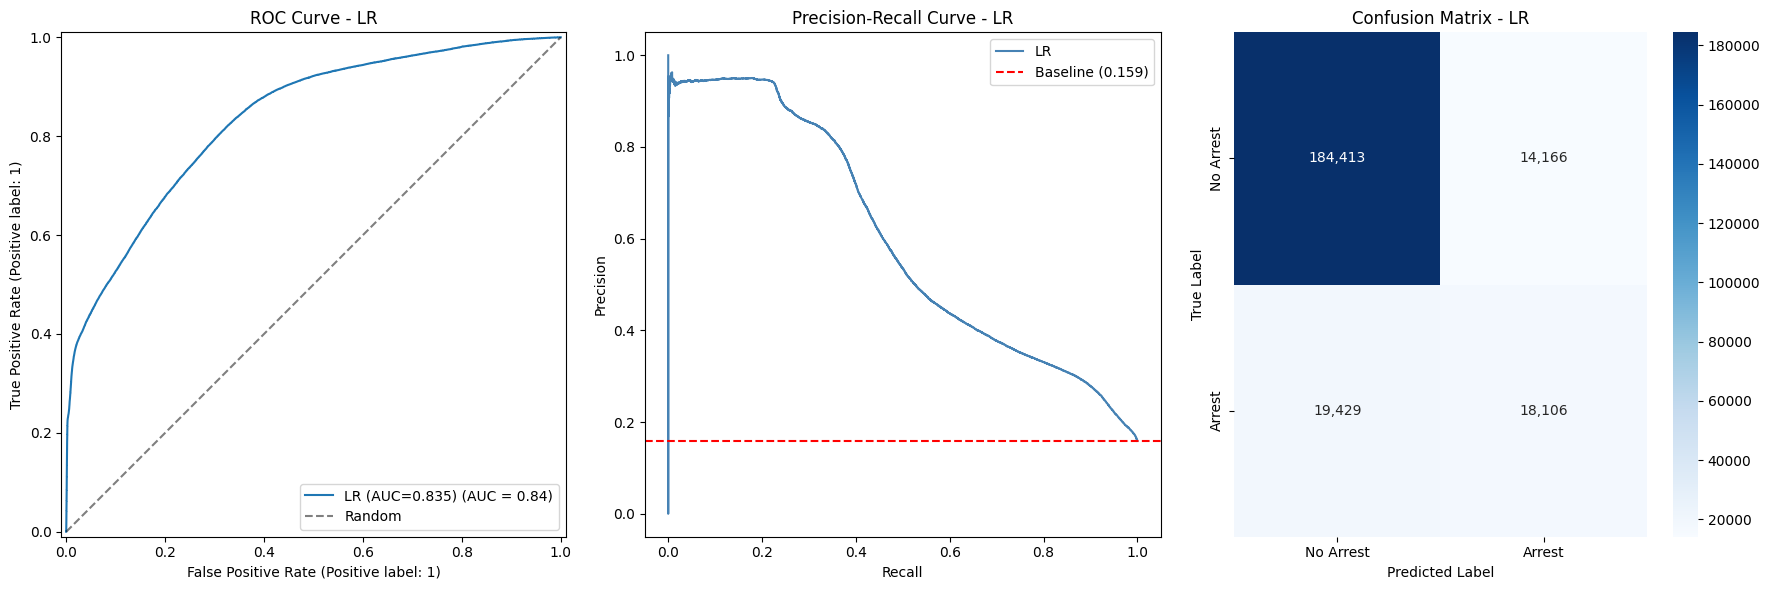

In [ ]:
# ROC + PR + Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f'LR (AUC={auc_lr:.3f})',
    ax=axes[0]
)
axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
axes[0].set_title('ROC Curve - LR')
axes[0].legend()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_lr)
axes[1].plot(rec, prec, color='steelblue', label='LR')
axes[1].axhline(y=y_test.mean(), color='red', linestyle='--',
                label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - LR')
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[2],
            xticklabels=['No Arrest','Arrest'],
            yticklabels=['No Arrest','Arrest'])
axes[2].set_title('Confusion Matrix - LR')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('lr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


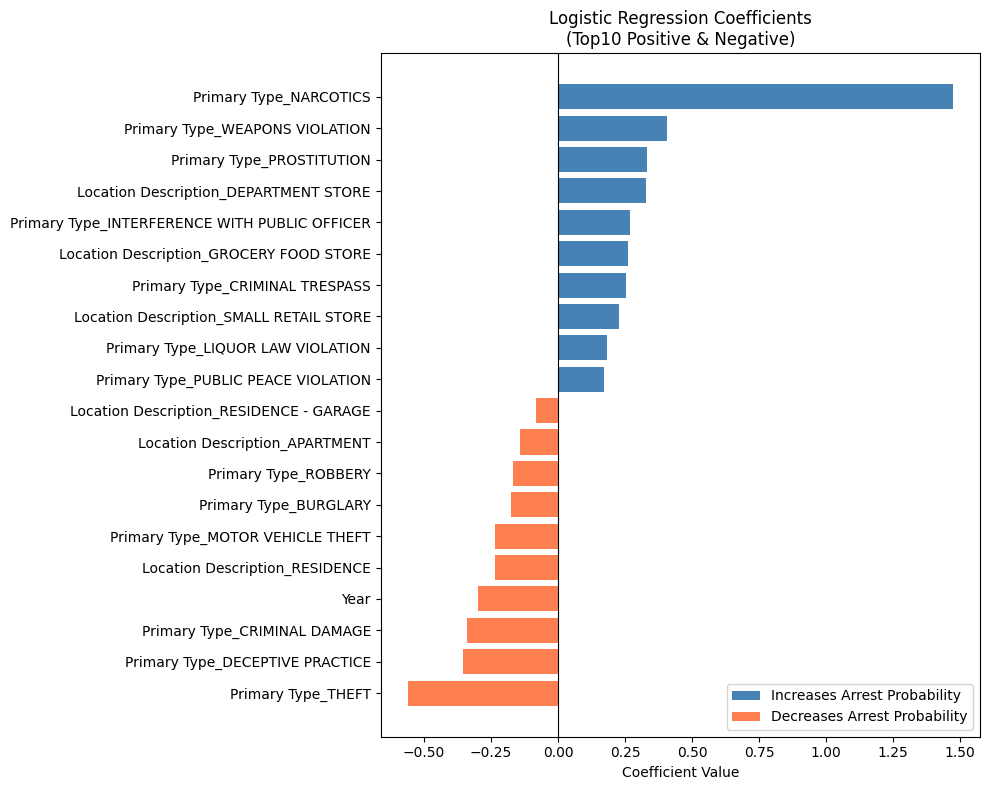

In [ ]:
# coeficient analysis
lr_model = lr_pipeline.named_steps['lr']
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

top_pos = coef_df.head(10)
top_neg = coef_df.tail(10).sort_values('Coefficient', ascending=False)
top_features = pd.concat([top_pos, top_neg])

top_features = top_features.sort_values('Coefficient', ascending=True)
colors = ['steelblue' if c > 0 else 'coral'
          for c in top_features['Coefficient']]

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Top10 Positive & Negative)')
plt.xlabel('Coefficient Value')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Increases Arrest Probability'),
                   Patch(facecolor='coral', label='Decreases Arrest Probability')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()



   District  Count  Arrest_rate  LR_AUC  LR_F1_macro  LR_Precision  LR_Recall
2        11  12910       0.3022  0.9180       0.8646        0.7752     0.7752
1        10   9485       0.2613  0.8690       0.7848        0.5940     0.5940
19        7  10091       0.1912  0.8486       0.7565        0.5189     0.5189
17        5   9252       0.1766  0.8483       0.7336        0.4902     0.4902
5        15   7804       0.1836  0.8476       0.7773        0.5736     0.5736
3        12  14846       0.0983  0.8362       0.6910        0.4064     0.4064
10        2  12639       0.1082  0.8353       0.6966        0.4265     0.4265
16        4  13039       0.1264  0.8349       0.6883        0.3890     0.3890
0         1  13643       0.1831  0.8301       0.7086        0.5833     0.5833
15        3  12683       0.1478  0.8268       0.7112        0.4213     0.4213
6        16   8038       0.1592  0.8259       0.7080        0.4437     0.4437
18        6  13540       0.1428  0.8190       0.6845        0.39

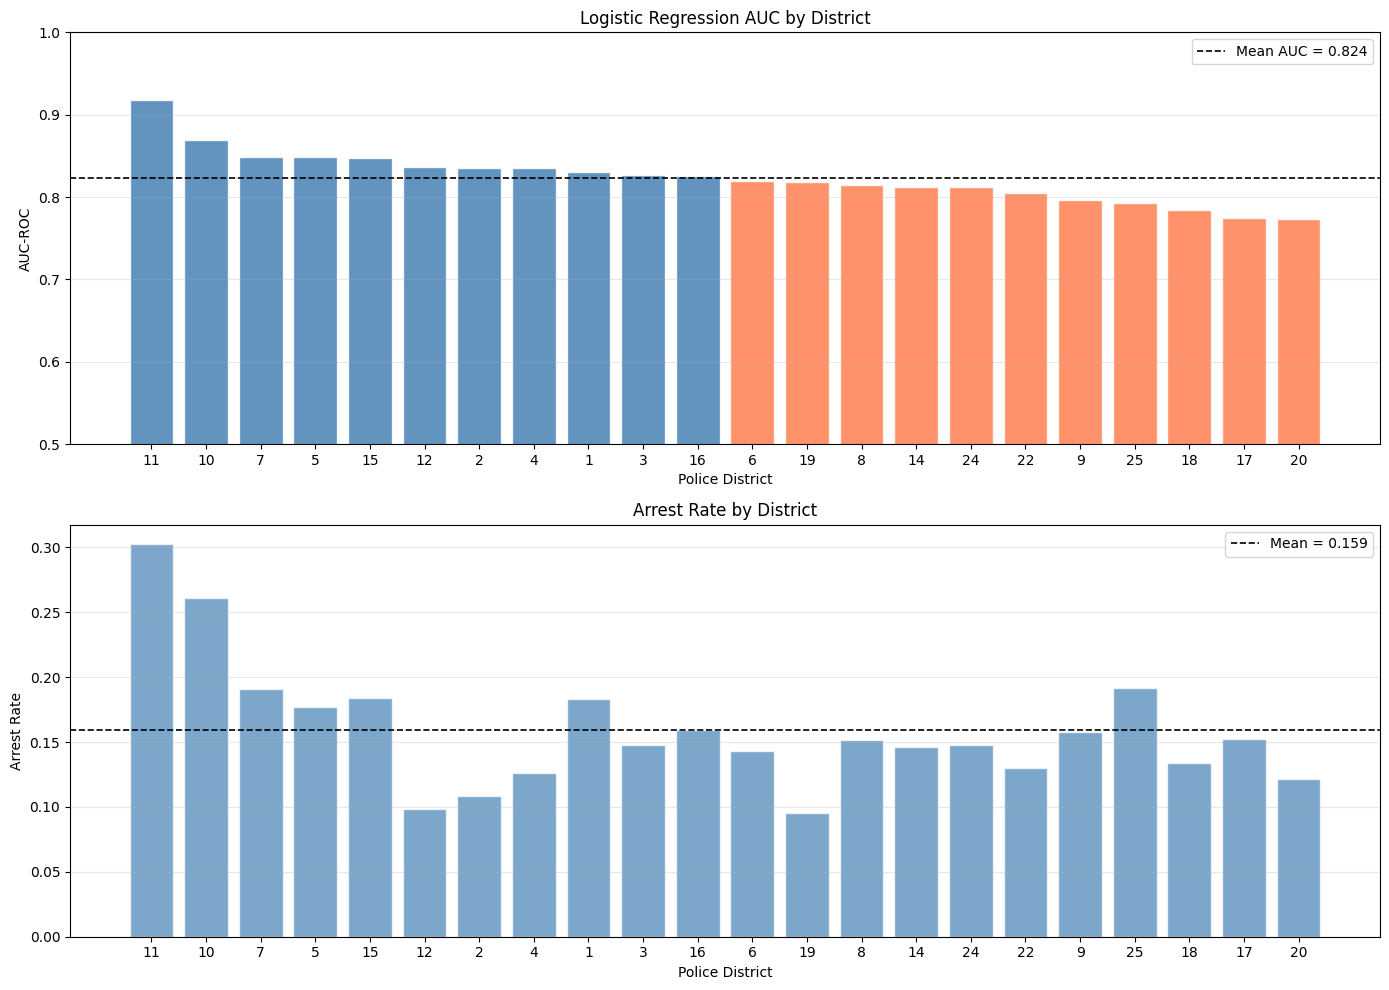

20028

In [ ]:
# Spatial Evaluation
district_cols = [c for c in test_df.columns if 'District_' in c]
test_df['District_label'] = 'Unknown'
for col in district_cols:
    mask = test_df[col] == 1
    test_df.loc[mask, 'District_label'] = col.replace('District_', '')

test_df['y_prob'] = y_prob_lr
test_df['y_pred'] = y_pred_lr

spatial_results = []
for district in sorted(test_df['District_label'].unique()):
    if district == 'Unknown':
        continue
    mask = test_df['District_label'] == district
    if mask.sum() < 100:
        continue

    y_true = test_df.loc[mask, 'Arrest'].values
    y_prob = test_df.loc[mask, 'y_prob'].values
    y_pred = test_df.loc[mask, 'y_pred'].values

    if y_true.sum() == 0 or y_true.sum() == mask.sum():
        continue

    spatial_results.append({
        'District':     district,
        'Count':        int(mask.sum()),
        'Arrest_rate':  round(float(y_true.mean()), 4),
        'LR_AUC':       round(float(roc_auc_score(y_true, y_prob)), 4),
        'LR_F1_macro':  round(float(f1_score(y_true, y_pred, average='macro')), 4),
        'LR_Precision': round(float(y_pred[y_true==1].mean()), 4),
        'LR_Recall':    round(float((y_pred[y_true==1]==1).mean()), 4),
    })

spatial_df = pd.DataFrame(spatial_results).sort_values('LR_AUC', ascending=False)
print(spatial_df.to_string())

print(f"\nAUC Mean:   {spatial_df['LR_AUC'].mean():.4f}")
print(f"AUC Std: {spatial_df['LR_AUC'].std():.4f}")
print(f"AUC Range:   [{spatial_df['LR_AUC'].min():.4f}, {spatial_df['LR_AUC'].max():.4f}]")
print(f"\nHighest AUC District: {spatial_df.iloc[0]['District']} ({spatial_df.iloc[0]['LR_AUC']})")
print(f"Lowest AUC District: {spatial_df.iloc[-1]['District']} ({spatial_df.iloc[-1]['LR_AUC']})")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

colors = ['steelblue' if v >= spatial_df['LR_AUC'].mean()
          else 'coral' for v in spatial_df['LR_AUC']]
axes[0].bar(spatial_df['District'], spatial_df['LR_AUC'],
            color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(y=spatial_df['LR_AUC'].mean(), color='black',
                linestyle='--', linewidth=1.2,
                label=f"Mean AUC = {spatial_df['LR_AUC'].mean():.3f}")
axes[0].set_xlabel('Police District')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Logistic Regression AUC by District')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(spatial_df['District'],
            spatial_df['Arrest_rate'],
            color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axhline(y=spatial_df['Arrest_rate'].mean(), color='black',
                linestyle='--', linewidth=1.2,
                label=f"Mean = {spatial_df['Arrest_rate'].mean():.3f}")
axes[1].set_xlabel('Police District')
axes[1].set_ylabel('Arrest Rate')
axes[1].set_title('Arrest Rate by District')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('lr_spatial_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

del test_df
gc.collect()

Year 2014: n=275,882 | AUC=0.873 | Arrest_rate=28.9%
Year 2015: n=264,887 | AUC=0.871 | Arrest_rate=26.5%
Year 2016: n=269,953 | AUC=0.848 | Arrest_rate=19.7%
Year 2017: n=269,282 | AUC=0.847 | Arrest_rate=19.6%
Year 2018: n=269,141 | AUC=0.849 | Arrest_rate=20.0%
Year 2019: n=261,694 | AUC=0.850 | Arrest_rate=21.5%
Year 2020: n=212,694 | AUC=0.847 | Arrest_rate=16.1%
Year 2021: n=209,639 | AUC=0.849 | Arrest_rate=12.7%
Year 2022: n=239,979 | AUC=0.845 | Arrest_rate=11.8%
Year 2023: n=263,250 | AUC=0.835 | Arrest_rate=12.2%
Year 2024: n=258,950 | AUC=0.829 | Arrest_rate=13.8%
Year 2025: n=236,114 | AUC=0.835 | Arrest_rate=15.9%
    Year   Count  Arrest_rate  LR_AUC  LR_F1_macro
0   2014  275882       0.2888  0.8730       0.7130
1   2015  264887       0.2646  0.8713       0.7089
2   2016  269953       0.1966  0.8476       0.6797
3   2017  269282       0.1957  0.8466       0.6925
4   2018  269141       0.2003  0.8493       0.7070
5   2019  261694       0.2151  0.8499       0.7223
6   202

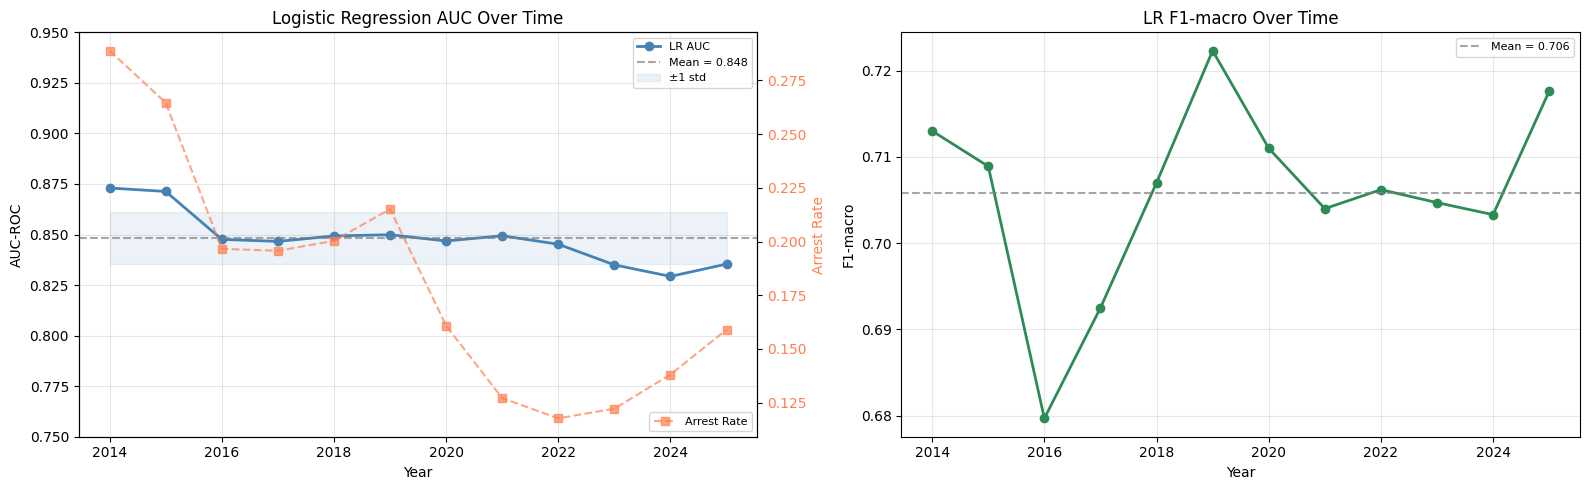

In [16]:
# Temporal Evaluation
temporal_results = []
years = pd.read_parquet('chicago_features_final.parquet', columns=['Year'])['Year'].unique()

for year in sorted(years):
    chunk = pd.read_parquet(
        'chicago_features_final.parquet',
        filters=[('Year', '==', year)]
    )
    feat_cols = [c for c in chunk.columns if c != 'Arrest']

    y_true = chunk['Arrest'].values
    X_sub  = chunk[feat_cols].values.astype(np.float32)

    if len(y_true) < 1000 or y_true.sum() == 0:
        del chunk, X_sub, y_true
        gc.collect()
        continue

    y_prob = lr_pipeline.predict_proba(X_sub)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    temporal_results.append({
        'Year':        int(year),
        'Count':       int(len(y_true)),
        'Arrest_rate': round(float(y_true.mean()), 4),
        'LR_AUC':      round(float(roc_auc_score(y_true, y_prob)), 4),
        'LR_F1_macro': round(float(f1_score(y_true, y_pred, average='macro')), 4),
    })
    print(f"Year {year}: n={len(y_true):,} | "
          f"AUC={temporal_results[-1]['LR_AUC']:.3f} | "
          f"Arrest_rate={y_true.mean()*100:.1f}%")

    del chunk, X_sub, y_true, y_prob, y_pred
    gc.collect()

temporal_df = pd.DataFrame(temporal_results)
print(temporal_df.to_string())

print(f"\nAUC Mean:   {temporal_df['LR_AUC'].mean():.4f}")
print(f"AUC Std:  {temporal_df['LR_AUC'].std():.4f}")
print(f"AUC Range:   [{temporal_df['LR_AUC'].min():.4f}, {temporal_df['LR_AUC'].max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(temporal_df['Year'], temporal_df['LR_AUC'],
             marker='o', color='steelblue', linewidth=2, label='LR AUC')
axes[0].axhline(y=temporal_df['LR_AUC'].mean(), color='gray',
                linestyle='--', alpha=0.7,
                label=f"Mean = {temporal_df['LR_AUC'].mean():.3f}")

axes[0].fill_between(
    temporal_df['Year'],
    temporal_df['LR_AUC'].mean() - temporal_df['LR_AUC'].std(),
    temporal_df['LR_AUC'].mean() + temporal_df['LR_AUC'].std(),
    alpha=0.1, color='steelblue', label='±1 std'
)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Logistic Regression AUC Over Time')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.75, 0.95)

ax2 = axes[0].twinx()
ax2.plot(temporal_df['Year'], temporal_df['Arrest_rate'],
         marker='s', color='coral', linewidth=1.5,
         linestyle='--', alpha=0.7, label='Arrest Rate')
ax2.set_ylabel('Arrest Rate', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')
ax2.legend(loc='lower right', fontsize=8)

axes[1].plot(temporal_df['Year'], temporal_df['LR_F1_macro'],
             marker='o', color='seagreen', linewidth=2)
axes[1].axhline(y=temporal_df['LR_F1_macro'].mean(), color='gray',
                linestyle='--', alpha=0.7,
                label=f"Mean = {temporal_df['LR_F1_macro'].mean():.3f}")

axes[1].set_xlabel('Year')
axes[1].set_ylabel('F1-macro')
axes[1].set_title('LR F1-macro Over Time')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lr_temporal_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Cross-validation
print(f"Temporal CV:")
print(f"  AUC   = {temporal_df['LR_AUC'].mean():.4f} ± "
      f"{temporal_df['LR_AUC'].std():.4f} "
      f"[{temporal_df['LR_AUC'].min():.4f}, "
      f"{temporal_df['LR_AUC'].max():.4f}]")
print(f"  F1    = {temporal_df['LR_F1_macro'].mean():.4f} ± "
      f"{temporal_df['LR_F1_macro'].std():.4f}")

print(f"\nSpatial CV:")
print(f"  AUC   = {spatial_df['LR_AUC'].mean():.4f} ± "
      f"{spatial_df['LR_AUC'].std():.4f} "
      f"[{spatial_df['LR_AUC'].min():.4f}, "
      f"{spatial_df['LR_AUC'].max():.4f}]")
print(f"  F1    = {spatial_df['LR_F1_macro'].mean():.4f} ± "
      f"{spatial_df['LR_F1_macro'].std():.4f}")

spatial_df.to_csv('lr_spatial_results.csv', index=False)
temporal_df.to_csv('lr_temporal_results.csv', index=False)

Temporal CV:
  AUC   = 0.8482 ± 0.0130 [0.8293, 0.8730]
  F1    = 0.7058 ± 0.0112

Spatial CV:
  AUC   = 0.8237 ± 0.0326 [0.7734, 0.9180]
  F1    = 0.7008 ± 0.0551
